# Welcome to Colab!

First 5 Rows
         Date  Temperature  Humidity Day_Type  Electricity_Consumption
0  2023-01-01           26        35  Weekday                    298.5
1  2023-01-02           39        35  Weekend                    291.5
2  2023-01-03           34        84  Weekend                    319.0
3  2023-01-04           30        77  Weekend                    305.5
4  2023-01-05           27        33  Weekend                    240.5

Dataset Shape: (1000, 5)

========== MODEL EVALUATION ==========
MAE : 14.36
MSE : 281.48
RMSE: 16.78
R2 Score: 0.89


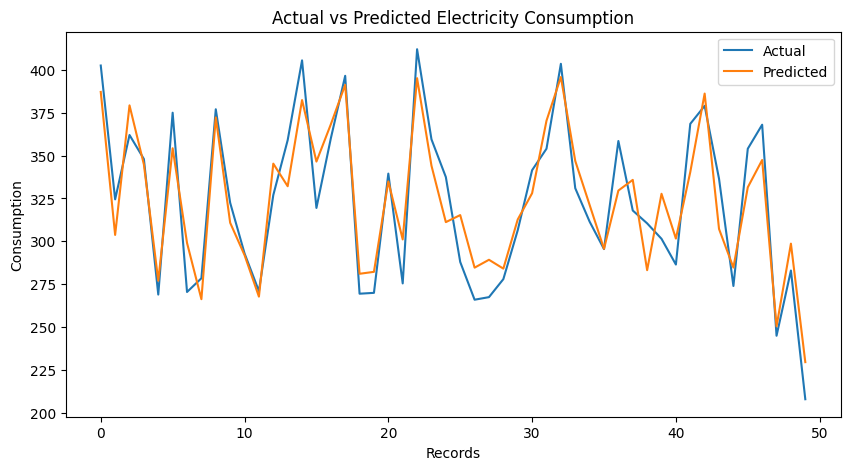

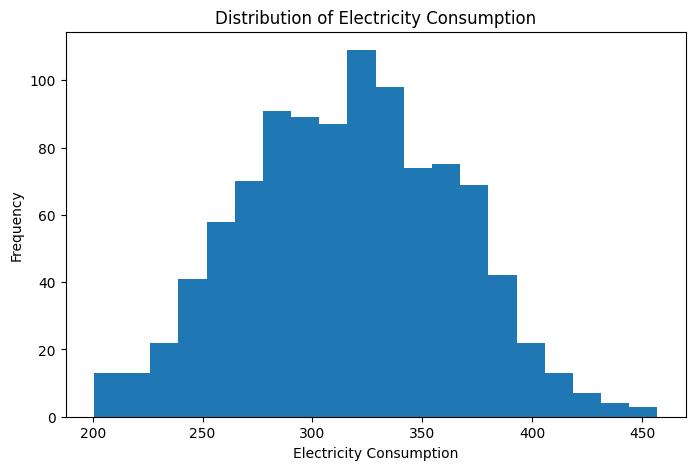

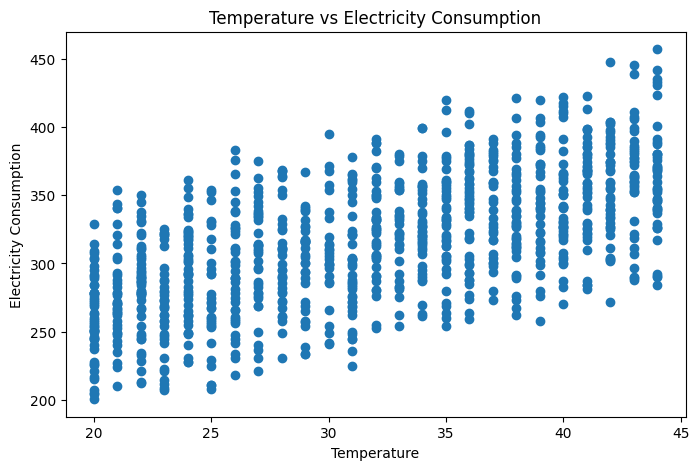

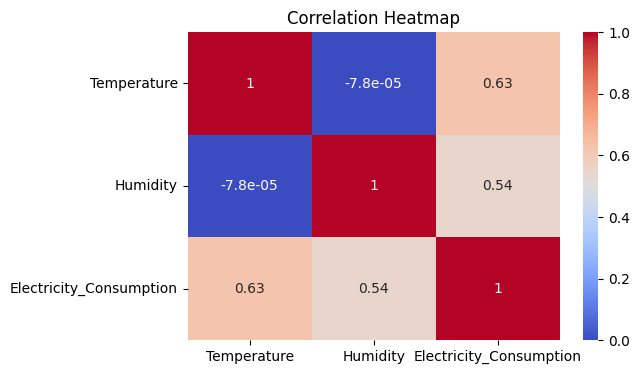


========== FUTURE PREDICTION ==========
Predicted Electricity Consumption: 309.74


In [ ]:
# ==========================
# Electricity Consumption Prediction
# Complete Project Code
# ==========================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Dataset
df = pd.read_csv('electricity_consumption.csv')

print("First 5 Rows")
print(df.head())

print("\nDataset Shape:", df.shape)

# Convert Categorical Data
le = LabelEncoder()
df['Day_Type'] = le.fit_transform(df['Day_Type'])

# Features and Target
X = df[['Temperature', 'Humidity', 'Day_Type']]
y = df['Electricity_Consumption']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n========== MODEL EVALUATION ==========")
print("MAE :", round(mae, 2))
print("MSE :", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R2 Score:", round(r2, 2))

# =====================================
# CHART 1 - Actual vs Predicted
# =====================================

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:50], label='Actual')
plt.plot(y_pred[:50], label='Predicted')
plt.title('Actual vs Predicted Electricity Consumption')
plt.xlabel('Records')
plt.ylabel('Consumption')
plt.legend()
plt.show()

# =====================================
# CHART 2 - Distribution
# =====================================

plt.figure(figsize=(8,5))
plt.hist(df['Electricity_Consumption'], bins=20)
plt.title('Distribution of Electricity Consumption')
plt.xlabel('Electricity Consumption')
plt.ylabel('Frequency')
plt.show()

# =====================================
# CHART 3 - Temperature vs Consumption
# =====================================

plt.figure(figsize=(8,5))
plt.scatter(df['Temperature'], df['Electricity_Consumption'])
plt.title('Temperature vs Electricity Consumption')
plt.xlabel('Temperature')
plt.ylabel('Electricity Consumption')
plt.show()

# =====================================
# CHART 4 - Correlation Heatmap
# =====================================

plt.figure(figsize=(6,4))
sns.heatmap(
    df[['Temperature','Humidity','Electricity_Consumption']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation Heatmap')
plt.show()

# =====================================
# Future Prediction
# =====================================

future_data = pd.DataFrame({
    'Temperature': [35],
    'Humidity': [60],
    'Day_Type': [1]
})

future_prediction = model.predict(future_data)

print("\n========== FUTURE PREDICTION ==========")
print("Predicted Electricity Consumption:",
      round(future_prediction[0], 2))